# Fitting spectroscopy

## What you will do
Fit an SDSS-like optical spectrum alone to constrain stellar age and metallicity. You'll see what spectroscopy constrains sharply (age, metallicity via absorption lines) and what stays loose (absolute dust optical depth).

## What you need
An SSP grid at R ≳ 2000, an observed optical spectrum (e.g., 3800–9200 Å), and a spectroscopic approximation (SpectrumPrecomp) for fast forward passes.

## What you will have
A posterior with tight age and metallicity but loose dust normalization—the reason to combine spectroscopy with photometry.

---

Broadband photometry alone leaves stellar metallicity and dust prior-dominated. An optical spectrum carries absorption-line depths — Hβ, the Mgb triplet, the Fe blends — that pin stellar age and metallicity. This notebook fits a spectrum alone using the same machinery as the quickstart (SEDModel.build with a fixed-length HMC sampler) and shows what it constrains and what stays degenerate. The absolute dust optical depth remains loose because a spectrum sets the continuum shape, not its normalization. Adding photometry closes that degeneracy in [`07_joint_photo_spec`](07_joint_photo_spec.ipynb).

In [1]:
import os
import warnings

# Four host devices so the four chains run in parallel.
os.environ["TENGRI_HOST_DEVICES"] = "4"

from _setup import FIG_DIR, quiet

quiet()

# Notebook-specific: we pair the wNE SSP with baked-in nebular, as intended.
warnings.filterwarnings("ignore", message=".*wNE.*")

import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    builders,
    Data,
    DEFAULT,
    Fixed,
    ForwardModel,
    FREE,
    Observation,
    plot,
    SEDModel,
    Spectroscopy,
    SpectrumPrecomp,
    Uniform,
)

plot.setup_style()

C_POST, C_TRUTH, C_DATA = "#3a76d9", "0.15", "#c3372a"

## Stellar library and observation

An SDSS-like R≈2000 optical spectrum, 3800–9200 Å observed (rest-frame
3620–8760 Å at z = 0.05: the 4000 Å break, Hβ, Mgb, the Fe blends, Hα, and
the Ca II triplet), sampled at 260 pixels to keep the demo fast, on an FSPS
grid with nebular emission baked into the templates at fixed ionization and
escape fraction.

In [2]:
SSP_NAME = "prsc_miles_chabrier_wNE"
ssp = tengri.load_ssp(SSP_NAME, download=True)

Z_GAL = 0.05
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 260)  # SDSS spectral coverage
obs = Observation(spectroscopy=Spectroscopy(wave_obs=WAVE_OBS, resolution=2000))

## Build the model

Truncated-skew-normal SFH (normalization + two timescales free; skew and
truncation fixed), free stellar metallicity, and two dust optical depths —
the same physics as notebooks 05 and 07, so the three are comparable.

In [3]:
# approx=SpectrumPrecomp() pre-rebins the SSP to the spectrum pixel centers and
# projects every forward pass through that lookup table — within ~0.03% of the
# exact wave-grid spectrum but ~30x faster per evaluation, so a posterior takes
# seconds. It is the spectroscopic analog of WavePrecomp; valid for low-to-medium
# resolution (R ≲ a few thousand), where the continuum is smooth across a pixel.
sed_model = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    approx=SpectrumPrecomp(),
    sfh=builders.sfh.tsnorm(
        all_params=Fixed(DEFAULT), log_total_mass=FREE, peak_lbt_gyr=FREE, width_gyr=FREE
    ),
    dust_attenuation=builders.dust.two_component(
        all_params=Fixed(DEFAULT),
        law="calzetti",
        tau_bc=Uniform(0.0, 1.0),
        tau_diff=Uniform(0.0, 1.0),
    ),
    neb={"type": "ssp"},
    met={"logzsol": Uniform(-1.5, 0.3)},
    redshift=Fixed(Z_GAL),
)
forward = ForwardModel.build(sed=sed_model)
print(f"Free parameters ({sed_model.spec.n_free}): {', '.join(sed_model.spec.free_params)}")

Free parameters (6): dust_tau_bc, dust_tau_diff, met_logzsol, sfh_tsnorm_log_total_mass, sfh_tsnorm_peak_lbt_gyr, sfh_tsnorm_width_gyr


## Mock observation

Truth with an interior metallicity; one noisy realization at S/N = 30 per
pixel.

In [4]:
truth = sed_model.spec.sample(jax.random.PRNGKey(0))
truth = {
    **truth,
    "met_logzsol": jnp.array(-0.30),
    "dust_tau_bc": jnp.array(0.30),
    "dust_tau_diff": jnp.array(0.25),
    "sfh_tsnorm_log_total_mass": jnp.array(10.5),
}
truth_full = {**sed_model.spec.get_fixed_values(), **{k: float(v) for k, v in truth.items()}}

p_spec = np.asarray(sed_model.predict_spectrum(truth_full, wave_obs=WAVE_OBS))
noise = p_spec / 30.0
flux = p_spec + np.random.default_rng(0).normal(size=p_spec.shape) * noise
wave_um = np.asarray(WAVE_OBS) / 1e4
print(f"Truth metallicity log(Z/Zsun) = {float(truth['met_logzsol']):+.2f}")
print(f"Mock: {len(flux)}-pixel R=2000 spectrum, SNR = 30/pixel")

Truth metallicity log(Z/Zsun) = -0.30
Mock: 260-pixel R=2000 spectrum, SNR = 30/pixel


## Fit

Fixed-length Hamiltonian Monte Carlo: four chains, 200 warmup and 300 draws
each, 50 leapfrog steps per draw. The sampler runs on the `SpectrumPrecomp`
lookup table and is preconditioned with the model's curvature at the best-fit
point, enabling a short trajectory to cross this posterior's geometry.

In [5]:
t0 = time.perf_counter()
posterior = forward.fit(
    Data(spectrum=(flux, noise)),
    key=jax.random.PRNGKey(1),
    verbose=False,
    method="mcmc_hmc",
    precondition=True,
    dense_mass_matrix=False,
    n_chains=4,
    n_warmup=200,
    n_samples=300,
    n_leapfrog_steps=50,
    profile_mass=False,
)
rhat = posterior.rhat()
rmax = max(float(v) for v in rhat.values())
print(f"{time.perf_counter() - t0:.0f} s   max R-hat {rmax:.3f}")

35 s   max R-hat 1.000


## Recovery — what a spectrum alone pins

Metallicity, stellar mass, and the SFH timescales recover tightly. The
diffuse dust optical depth is constrained (it shapes the continuum slope) but
the birth-cloud component `tau_bc` stays broad — a spectrum fixes the
continuum shape, not the overall dust normalization.

In [6]:
params = sed_model.spec.free_params
print(f"{'parameter':<28}{'truth':>9}{'p16':>9}{'p50':>9}{'p84':>9}  cover")
print("-" * 66)
n_cov = 0
for p in params:
    s = np.asarray(posterior.samples[p])
    lo, med, hi = np.percentile(s, [16, 50, 84])
    tv = float(truth_full[p])
    ok = lo <= tv <= hi
    n_cov += ok
    print(f"{p:<28}{tv:>9.3f}{lo:>9.3f}{med:>9.3f}{hi:>9.3f}  {'ok' if ok else 'miss'}")
print(f"\n68% coverage: {n_cov}/{len(params)}")

parameter                       truth      p16      p50      p84  cover
------------------------------------------------------------------
dust_tau_bc                     0.300    0.157    0.513    0.846  ok
dust_tau_diff                   0.250    0.211    0.251    0.289  ok
met_logzsol                    -0.300   -0.319   -0.259   -0.207  ok
sfh_tsnorm_log_total_mass      10.500   10.473   10.487   10.501  ok
sfh_tsnorm_peak_lbt_gyr         2.024    1.730    1.872    2.055  ok
sfh_tsnorm_width_gyr            0.483    0.294    0.394    0.499  ok

68% coverage: 6/6


## Posterior SED

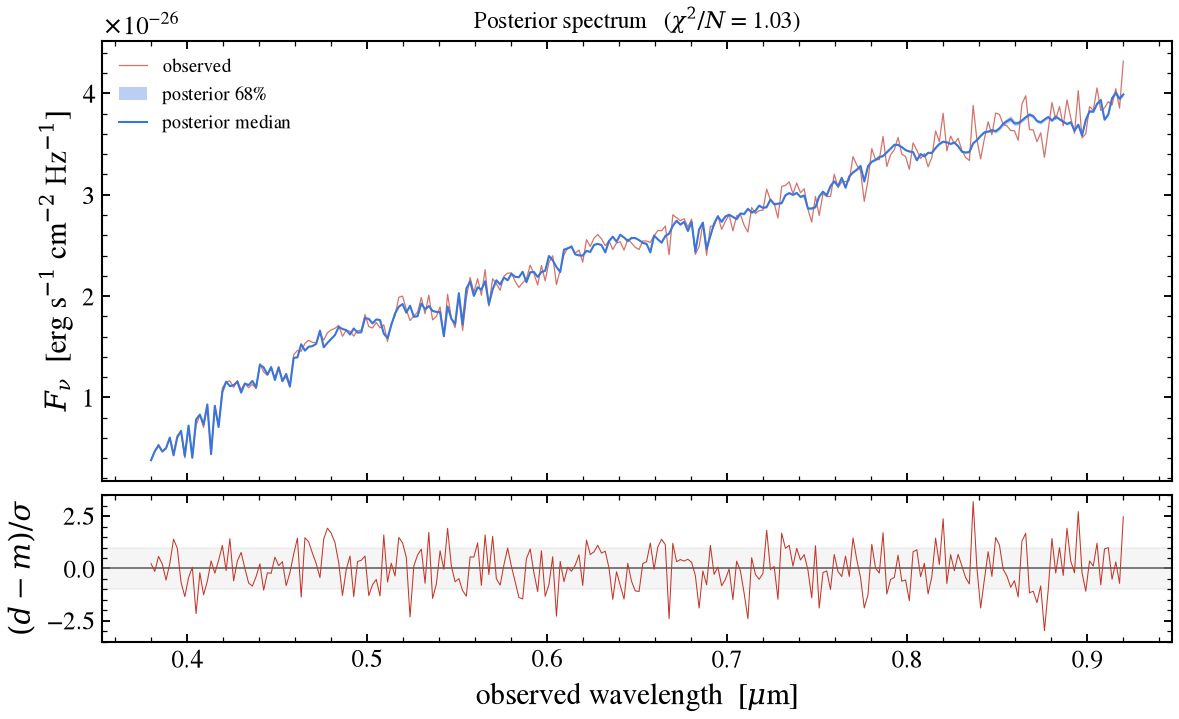

In [7]:
N_DRAW = 60
idx = np.linspace(0, len(next(iter(posterior.samples.values()))) - 1, N_DRAW).astype(int)
fixed = sed_model.spec.get_fixed_values()
draws = [{**fixed, **{k: float(v[i]) for k, v in posterior.samples.items()}} for i in idx]
spec_draws = np.stack(
    [np.asarray(sed_model.predict_spectrum(p, wave_obs=WAVE_OBS)) for p in draws]
)
sp_lo, sp_med, sp_hi = np.percentile(spec_draws, [16, 50, 84], axis=0)
resid = (flux - sp_med) / noise
chi2_dof = float(np.sum(resid**2) / len(resid))

fig = plt.figure(figsize=(9.2, 5.2))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
ax, ax_r = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
ax.plot(wave_um, flux, color=C_DATA, lw=0.6, alpha=0.7, label="observed")
ax.fill_between(wave_um, sp_lo, sp_hi, color=C_POST, alpha=0.35, lw=0, label="posterior 68%")
ax.plot(wave_um, sp_med, color=C_POST, lw=1.0, label="posterior median")
ax.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.set_title(rf"Posterior spectrum   ($\chi^2/N$ = {chi2_dof:.2f})", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.setp(ax.get_xticklabels(), visible=False)
ax_r.axhspan(-1, 1, alpha=0.08, color="0.5")
ax_r.axhline(0, color="0.4", lw=0.8)
ax_r.plot(wave_um, resid, color=C_DATA, lw=0.5)
ax_r.set_ylim(-3.5, 3.5)
ax_r.set_xlabel(r"observed wavelength  [$\mu$m]")
ax_r.set_ylabel(r"$(d-m)/\sigma$")
fig.savefig(FIG_DIR / "06_spectrum_fit.png", dpi=300, bbox_inches="tight")
plt.show()

## Corner

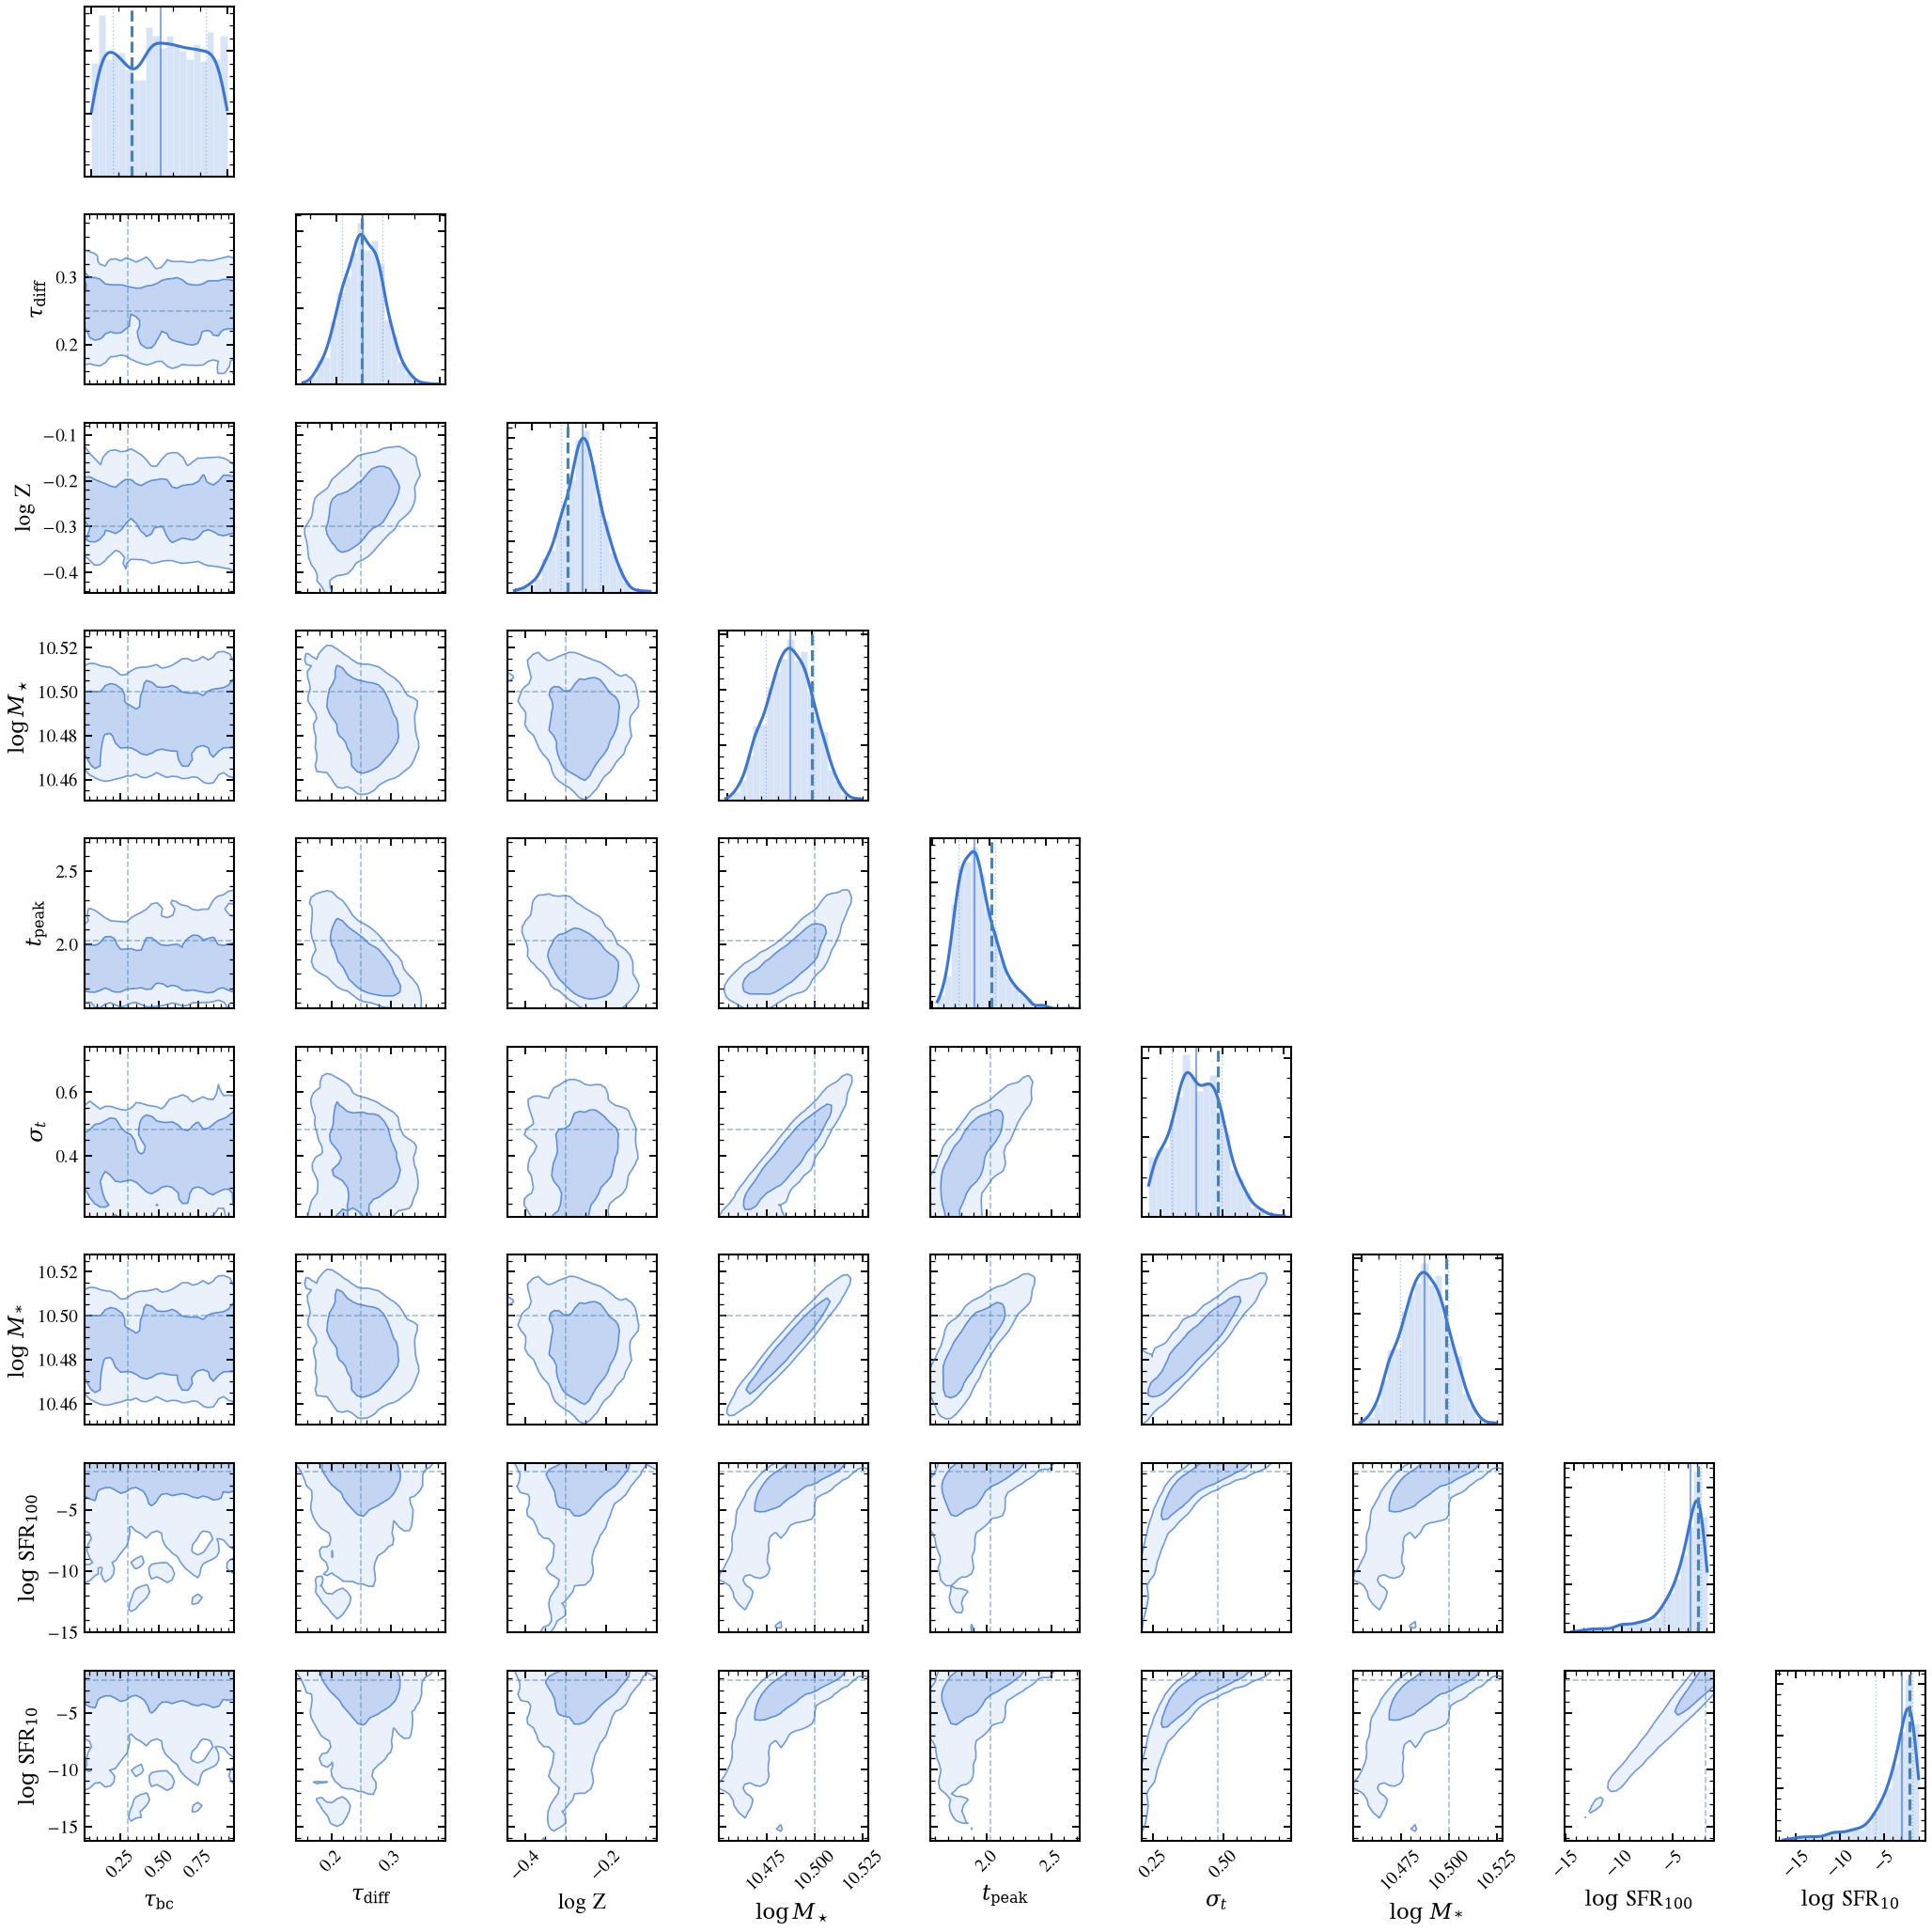

In [8]:
labels = {
    "met_logzsol": r"$\log Z/Z_\odot$",
    "dust_tau_bc": r"$\tau_{\rm bc}$",
    "dust_tau_diff": r"$\tau_{\rm diff}$",
    "sfh_tsnorm_log_total_mass": r"$\log M_\star$",
    "sfh_tsnorm_peak_lbt_gyr": r"$t_{\rm peak}$",
    "sfh_tsnorm_width_gyr": r"$\sigma_t$",
}
fig_corner = posterior.plot_corner(truths=truth_full, color=C_POST)
for ax_c in fig_corner.axes:  # readable axis labels in place of parameter keys
    if ax_c.get_xlabel() in labels:
        ax_c.set_xlabel(labels[ax_c.get_xlabel()], fontsize=11)
    if ax_c.get_ylabel() in labels:
        ax_c.set_ylabel(labels[ax_c.get_ylabel()], fontsize=11)
fig_corner.savefig(FIG_DIR / "06_corner.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary

The fit takes 35 s; max R-hat 1.000. Spectroscopy alone recovers
stellar age, metallicity, and mass sharply from the absorption features; dust
normalization remains loose. [`07_joint_photo_spec`](07_joint_photo_spec.ipynb)
adds broadband photometry, which fixes dust and tightens convergence.